# Backtest — Trade Signal Strategy

**Simulasi logika `TradeSignalUsecase` tanpa MT5** menggunakan data historis CSV.

**Strategi yang di-backtest (sama persis dengan usecase.py):**
- H1 Trend Filter: EMA50 vs EMA200
- M15 Entry: minimal 3/4 indikator searah (RSI, MACD, EMA 9/21, Bollinger Bands)
- Filter ATR: skip jika ATR < 5 pips
- SL = 1.0x ATR, TP = 1.5x ATR (RR 1:1.5)

**Data:** `EURUSD_M15` Des 2021 - Mar 2026 (100,267 candle)

## 1. Import & Load Data

In [1]:
import sys
sys.path.insert(0, '../../')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid')
plt.rcParams['figure.dpi'] = 100

# Load data M15
CSV_PATH = '../../app/ai/candle_ai/EURUSD.m_M15_202112160545_202603251830.csv'

df_m15 = pd.read_csv(CSV_PATH, sep='\t')
df_m15.columns = df_m15.columns.str.strip('<>').str.lower()
df_m15['datetime'] = pd.to_datetime(df_m15['date'] + ' ' + df_m15['time'])
df_m15 = df_m15.set_index('datetime').drop(columns=['date', 'time'])
df_m15 = df_m15.rename(columns={'tickvol': 'tick_vol'})
df_m15 = df_m15.sort_index()

print(f'M15 loaded: {df_m15.shape}')
print(f'Range: {df_m15.index.min()} → {df_m15.index.max()}')
df_m15.head(3)

M15 loaded: (100267, 7)
Range: 2021-12-16 05:45:00 → 2026-03-25 18:30:00


,open,high,low,close,tick_vol,vol,spread
datetime,,,,,,,
2021-12-16 05:45:00,1.12871,1.12878,1.12854,1.12856,88,0,2
2021-12-16 06:00:00,1.12857,1.12866,1.12849,1.12854,109,0,2
2021-12-16 06:15:00,1.12853,1.12869,1.12835,1.12849,118,0,2


## 2. Resample M15 → H1 (untuk Trend Filter)

In [2]:
# Resample M15 ke H1
df_h1 = df_m15.resample('1h').agg({
    'open':     'first',
    'high':     'max',
    'low':      'min',
    'close':    'last',
    'tick_vol': 'sum',
    'vol':      'sum',
    'spread':   'mean'
}).dropna()

print(f'H1 resampled: {df_h1.shape}')
print(f'Range: {df_h1.index.min()} → {df_h1.index.max()}')

H1 resampled: (26563, 7)
Range: 2021-12-16 05:00:00 → 2026-03-25 18:00:00


## 3. Hitung Indikator (sama dengan usecase.py)

In [3]:
def ema(series, period):
    return series.ewm(span=period, adjust=False).mean()

def rsi(series, period=14):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(period).mean()
    loss  = (-delta.clip(upper=0)).rolling(period).mean()
    rs    = gain / (loss + 1e-10)
    return 100 - (100 / (1 + rs))

def macd(series, fast=12, slow=26, signal=9):
    ema_fast   = ema(series, fast)
    ema_slow   = ema(series, slow)
    macd_line  = ema_fast - ema_slow
    signal_line = ema(macd_line, signal)
    histogram  = macd_line - signal_line
    return macd_line, signal_line, histogram

def bbands(series, period=20, std=2):
    mid   = series.rolling(period).mean()
    sigma = series.rolling(period).std()
    return mid + std * sigma, mid, mid - std * sigma

def atr(df, period=14):
    hl  = df['high'] - df['low']
    hc  = (df['high'] - df['close'].shift()).abs()
    lc  = (df['low']  - df['close'].shift()).abs()
    tr  = pd.concat([hl, hc, lc], axis=1).max(axis=1)
    return tr.rolling(period).mean()

# H1 indicators
df_h1['ema_50']  = ema(df_h1['close'], 50)
df_h1['ema_200'] = ema(df_h1['close'], 200)
df_h1['trend']   = np.where(df_h1['ema_50'] > df_h1['ema_200'], 'up',
                   np.where(df_h1['ema_50'] < df_h1['ema_200'], 'down', 'sideways'))

# M15 indicators
df_m15['rsi_14']     = rsi(df_m15['close'], 14)
ml, sl_line, mh      = macd(df_m15['close'])
df_m15['macd_line']  = ml
df_m15['macd_sig']   = sl_line
df_m15['ema_9']      = ema(df_m15['close'], 9)
df_m15['ema_21']     = ema(df_m15['close'], 21)
bb_u, bb_m, bb_l     = bbands(df_m15['close'])
df_m15['bb_mid']     = bb_m
df_m15['atr_14']     = atr(df_m15, 14)

print('Indikator H1 & M15 selesai dihitung.')

Indikator H1 & M15 selesai dihitung.


## 4. Generate Signal (Replikasi TradeSignalUsecase)

In [4]:
# Merge H1 trend ke M15 (forward fill — setiap candle M15 pakai trend H1 terakhir)
df_m15['h1_trend'] = df_h1['trend'].reindex(df_m15.index, method='ffill')

# Hitung bias per indikator M15 (sama persis dengan usecase.py)
df_m15['rsi_bias']  = np.where(df_m15['rsi_14'] <= 40, 'buy',
                      np.where(df_m15['rsi_14'] >= 60, 'sell', 'hold'))

df_m15['macd_bias'] = np.where(df_m15['macd_line'] > df_m15['macd_sig'], 'buy',
                      np.where(df_m15['macd_line'] < df_m15['macd_sig'], 'sell', 'hold'))

df_m15['ema_bias']  = np.where(df_m15['ema_9'] > df_m15['ema_21'], 'buy',
                      np.where(df_m15['ema_9'] < df_m15['ema_21'], 'sell', 'hold'))

df_m15['bb_bias']   = np.where(df_m15['close'] < df_m15['bb_mid'], 'buy',
                      np.where(df_m15['close'] > df_m15['bb_mid'], 'sell', 'hold'))

# Hitung jumlah buy/sell bias
biases = df_m15[['rsi_bias', 'macd_bias', 'ema_bias', 'bb_bias']]
df_m15['buy_cnt']  = (biases == 'buy').sum(axis=1)
df_m15['sell_cnt'] = (biases == 'sell').sum(axis=1)

# Generate signal (logika sama dengan usecase.py)
ATR_MIN = 0.0005  # 5 pips minimum

def get_signal(row):
    if pd.isna(row['atr_14']) or row['atr_14'] < ATR_MIN:
        return 'hold'
    if row['h1_trend'] == 'up'   and row['buy_cnt']  >= 3:
        return 'buy'
    if row['h1_trend'] == 'down' and row['sell_cnt'] >= 3:
        return 'sell'
    return 'hold'

df_m15['signal'] = df_m15.apply(get_signal, axis=1)

# SL / TP
SL_MULT = 1.0
TP_MULT = 1.5

df_m15['sl'] = np.where(df_m15['signal'] == 'buy',  df_m15['close'] - SL_MULT * df_m15['atr_14'],
               np.where(df_m15['signal'] == 'sell', df_m15['close'] + SL_MULT * df_m15['atr_14'], np.nan))

df_m15['tp'] = np.where(df_m15['signal'] == 'buy',  df_m15['close'] + TP_MULT * df_m15['atr_14'],
               np.where(df_m15['signal'] == 'sell', df_m15['close'] - TP_MULT * df_m15['atr_14'], np.nan))

print('Distribusi signal:')
print(df_m15['signal'].value_counts())
print()
pct = df_m15['signal'].value_counts(normalize=True).mul(100).round(1)
print(pct)

Distribusi signal:
signal
hold    96638
buy      1894
sell     1735
Name: count, dtype: int64

signal
hold    96.4
buy      1.9
sell     1.7
Name: proportion, dtype: float64


## 5. Backtest Engine — Simulasi Trade

In [5]:
# Backtest: setiap signal BUY/SELL, simulasi apakah hit TP atau SL
# Cek candle berikutnya sampai hit TP atau SL (max 20 candle = 5 jam)

LOT_SIZE   = 0.01   # lot per trade
PIP_VALUE  = 10     # USD per pip per 0.1 lot → $1 per pip untuk 0.01 lot
MAX_CANDLE = 20     # max hold 20 candle = 5 jam
SPREAD_PIP = 1      # 1 pip spread

df_trade = df_m15[df_m15['signal'].isin(['buy', 'sell'])].copy()
df_trade = df_trade.dropna(subset=['sl', 'tp'])

close_arr   = df_m15['close'].values
high_arr    = df_m15['high'].values
low_arr     = df_m15['low'].values
idx_arr     = df_m15.index
m15_indices = {dt: i for i, dt in enumerate(idx_arr)}

results = []

for dt, row in df_trade.iterrows():
    i      = m15_indices.get(dt)
    if i is None or i + MAX_CANDLE >= len(close_arr):
        continue

    entry  = row['close']
    sl     = row['sl']
    tp     = row['tp']
    signal = row['signal']
    atr_v  = row['atr_14']

    outcome    = 'timeout'
    exit_price = close_arr[i + MAX_CANDLE]
    exit_dt    = idx_arr[i + MAX_CANDLE]
    hold_candles = MAX_CANDLE

    for j in range(1, MAX_CANDLE + 1):
        h = high_arr[i + j]
        l = low_arr[i + j]

        if signal == 'buy':
            if l <= sl:
                outcome = 'loss'; exit_price = sl; exit_dt = idx_arr[i+j]; hold_candles = j; break
            if h >= tp:
                outcome = 'win';  exit_price = tp; exit_dt = idx_arr[i+j]; hold_candles = j; break
        else:  # sell
            if h >= sl:
                outcome = 'loss'; exit_price = sl; exit_dt = idx_arr[i+j]; hold_candles = j; break
            if l <= tp:
                outcome = 'win';  exit_price = tp; exit_dt = idx_arr[i+j]; hold_candles = j; break

    # Hitung P&L dalam pips
    if signal == 'buy':
        pnl_pips = (exit_price - entry) / 0.0001 - SPREAD_PIP
    else:
        pnl_pips = (entry - exit_price) / 0.0001 - SPREAD_PIP

    results.append({
        'entry_dt':     dt,
        'exit_dt':      exit_dt,
        'signal':       signal,
        'entry':        entry,
        'sl':           sl,
        'tp':           tp,
        'exit_price':   exit_price,
        'outcome':      outcome,
        'pnl_pips':     round(pnl_pips, 1),
        'hold_candles': hold_candles,
        'atr':          round(atr_v / 0.0001, 1),
        'h1_trend':     row['h1_trend'],
        'buy_cnt':      row['buy_cnt'],
        'sell_cnt':     row['sell_cnt'],
    })

bt = pd.DataFrame(results)
print(f'Total trade: {len(bt):,}')
print(f'Win: {(bt["outcome"]=="win").sum():,}')
print(f'Loss: {(bt["outcome"]=="loss").sum():,}')
print(f'Timeout: {(bt["outcome"]=="timeout").sum():,}')

Total trade: 3,627
Win: 1,293
Loss: 2,005
Timeout: 329


## 6. Hasil Backtest — Statistik

In [6]:
total   = len(bt)
wins    = (bt['outcome'] == 'win').sum()
losses  = (bt['outcome'] == 'loss').sum()
timeout = (bt['outcome'] == 'timeout').sum()
wr      = wins / total * 100

total_pips  = bt['pnl_pips'].sum()
avg_win     = bt[bt['outcome']=='win']['pnl_pips'].mean()
avg_loss    = bt[bt['outcome']=='loss']['pnl_pips'].mean()
avg_timeout = bt[bt['outcome']=='timeout']['pnl_pips'].mean()
profit_factor = bt[bt['pnl_pips']>0]['pnl_pips'].sum() / abs(bt[bt['pnl_pips']<0]['pnl_pips'].sum() + 1e-10)

bt_buy  = bt[bt['signal']=='buy']
bt_sell = bt[bt['signal']=='sell']

print('=' * 52)
print('          HASIL BACKTEST — TRADE SIGNAL')
print('=' * 52)
print(f'Periode       : Des 2021 - Mar 2026')
print(f'Symbol        : EURUSD M15')
print(f'Total Trade   : {total:,}')
print(f'Win           : {wins:,}  ({wr:.1f}%)')
print(f'Loss          : {losses:,}  ({losses/total*100:.1f}%)')
print(f'Timeout       : {timeout:,}  ({timeout/total*100:.1f}%)')
print(f'\nTotal Pips    : {total_pips:+.1f}')
print(f'Avg Win       : {avg_win:+.1f} pips')
print(f'Avg Loss      : {avg_loss:+.1f} pips')
print(f'Profit Factor : {profit_factor:.2f}')
print(f'\n--- Per Arah ---')
print(f'BUY  trades   : {len(bt_buy):,}  | WR: {(bt_buy["outcome"]=="win").mean()*100:.1f}%  | Pips: {bt_buy["pnl_pips"].sum():+.1f}')
print(f'SELL trades   : {len(bt_sell):,}  | WR: {(bt_sell["outcome"]=="win").mean()*100:.1f}%  | Pips: {bt_sell["pnl_pips"].sum():+.1f}')
print('=' * 52)

          HASIL BACKTEST — TRADE SIGNAL
Periode       : Des 2021 - Mar 2026
Symbol        : EURUSD M15
Total Trade   : 3,627
Win           : 1,293  (35.6%)
Loss          : 2,005  (55.3%)
Timeout       : 329  (9.1%)

Total Pips    : -3447.7
Avg Win       : +12.4 pips
Avg Loss      : -10.0 pips
Profit Factor : 0.83

--- Per Arah ---
BUY  trades   : 1,892  | WR: 35.3%  | Pips: -1499.9
SELL trades   : 1,735  | WR: 36.1%  | Pips: -1947.8


## 7. Equity Curve & Visualisasi

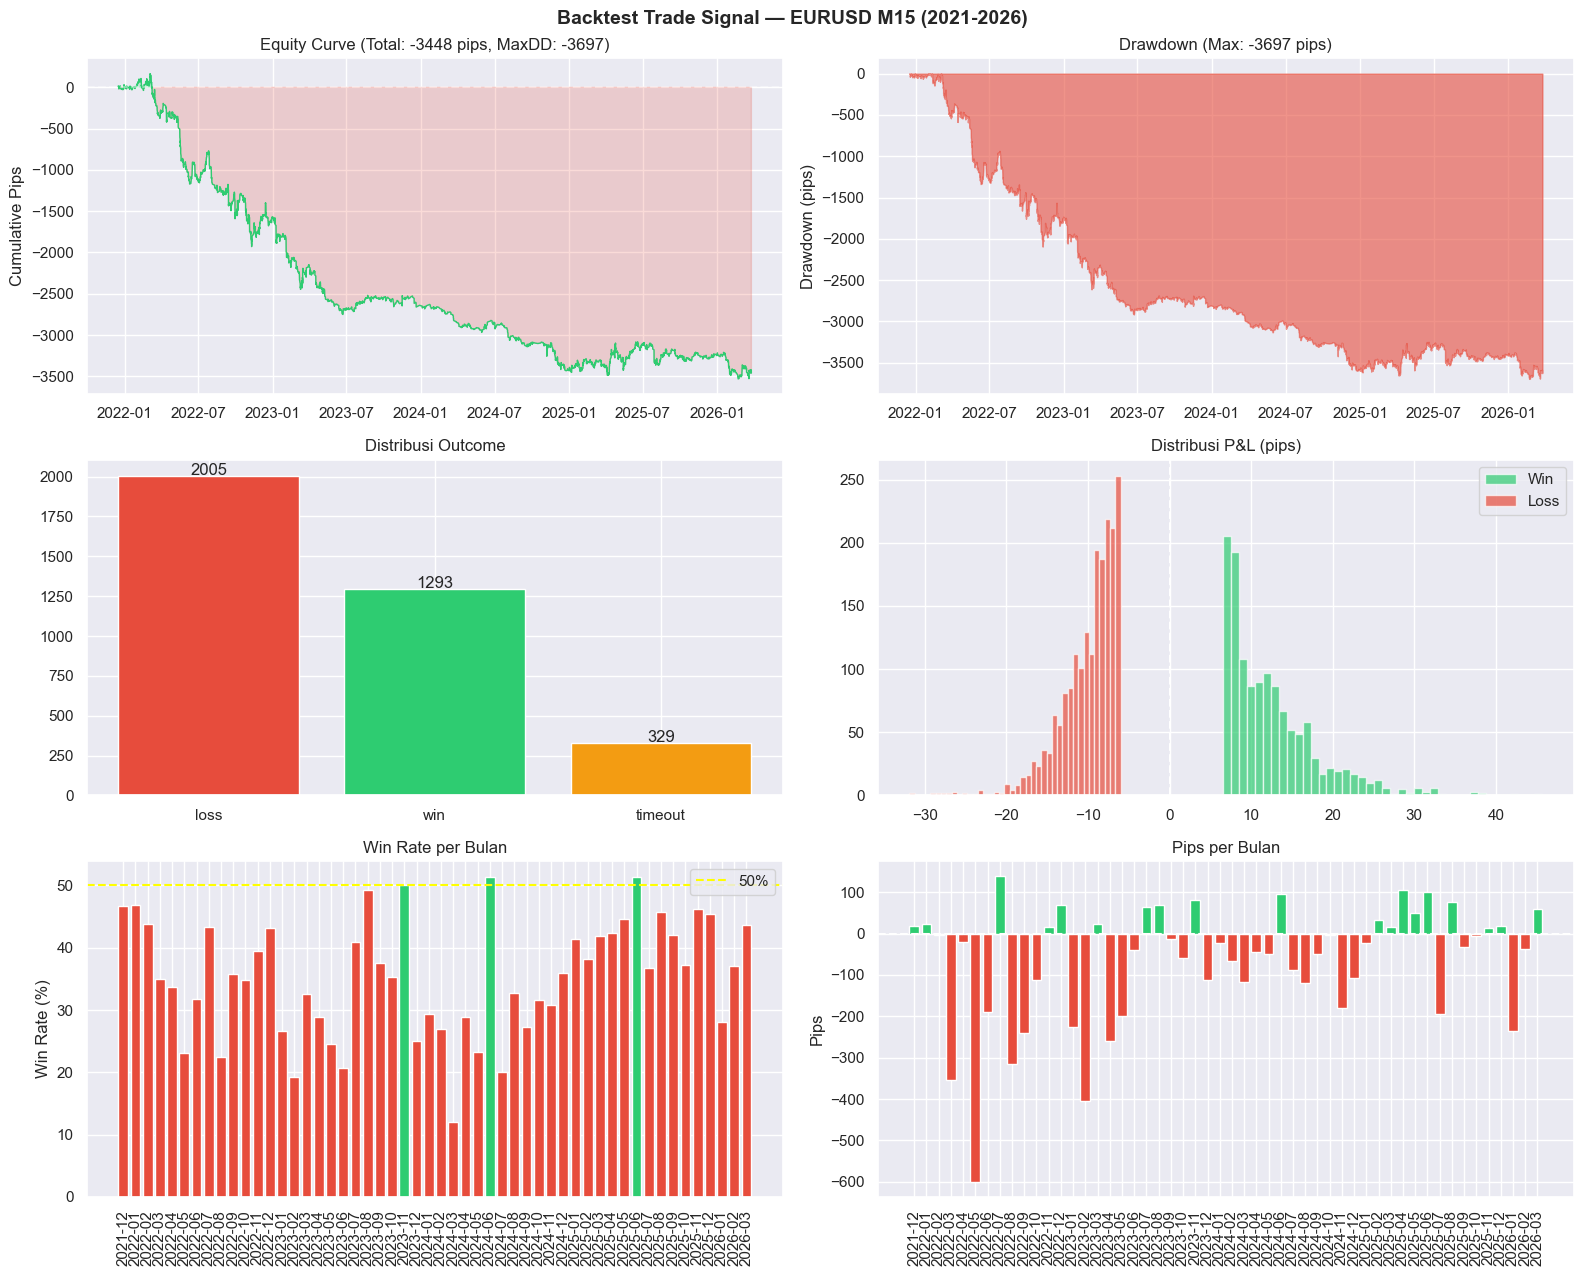

Chart disimpan: backtest_result.png


In [7]:
bt = bt.sort_values('entry_dt').reset_index(drop=True)
bt['cumulative_pips'] = bt['pnl_pips'].cumsum()

# Drawdown
running_max = bt['cumulative_pips'].cummax()
bt['drawdown'] = bt['cumulative_pips'] - running_max
max_dd = bt['drawdown'].min()

fig, axes = plt.subplots(3, 2, figsize=(16, 13))

# Equity curve
axes[0,0].plot(bt['entry_dt'], bt['cumulative_pips'], color='#2ecc71', linewidth=1)
axes[0,0].axhline(0, color='white', linestyle='--', alpha=0.4)
axes[0,0].fill_between(bt['entry_dt'], bt['cumulative_pips'], 0,
    where=bt['cumulative_pips']>=0, alpha=0.2, color='#2ecc71')
axes[0,0].fill_between(bt['entry_dt'], bt['cumulative_pips'], 0,
    where=bt['cumulative_pips']<0, alpha=0.2, color='#e74c3c')
axes[0,0].set_title(f'Equity Curve (Total: {total_pips:+.0f} pips, MaxDD: {max_dd:.0f})')
axes[0,0].set_ylabel('Cumulative Pips')
axes[0,0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Drawdown
axes[0,1].fill_between(bt['entry_dt'], bt['drawdown'], 0, color='#e74c3c', alpha=0.6)
axes[0,1].set_title(f'Drawdown (Max: {max_dd:.0f} pips)')
axes[0,1].set_ylabel('Drawdown (pips)')
axes[0,1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Distribusi outcome
outcome_counts = bt['outcome'].value_counts()
colors_out = {'win': '#2ecc71', 'loss': '#e74c3c', 'timeout': '#f39c12'}
axes[1,0].bar(outcome_counts.index, outcome_counts.values,
    color=[colors_out.get(k,'gray') for k in outcome_counts.index], edgecolor='white')
axes[1,0].set_title('Distribusi Outcome')
for i, (k, v) in enumerate(outcome_counts.items()):
    axes[1,0].text(i, v + 5, str(v), ha='center')

# P&L distribusi
bt[bt['outcome']=='win']['pnl_pips'].hist(bins=40, ax=axes[1,1], color='#2ecc71', alpha=0.7, label='Win')
bt[bt['outcome']=='loss']['pnl_pips'].hist(bins=40, ax=axes[1,1], color='#e74c3c', alpha=0.7, label='Loss')
axes[1,1].axvline(0, color='white', linestyle='--')
axes[1,1].set_title('Distribusi P&L (pips)')
axes[1,1].legend()

# Win rate per bulan
bt['month'] = bt['entry_dt'].dt.to_period('M')
monthly_wr = bt.groupby('month').apply(lambda x: (x['outcome']=='win').mean()*100).reset_index()
monthly_wr.columns = ['month', 'win_rate']
axes[2,0].bar(monthly_wr['month'].astype(str), monthly_wr['win_rate'],
    color=['#2ecc71' if v >= 50 else '#e74c3c' for v in monthly_wr['win_rate']], edgecolor='white')
axes[2,0].axhline(50, color='yellow', linestyle='--', label='50%')
axes[2,0].set_title('Win Rate per Bulan')
axes[2,0].set_ylabel('Win Rate (%)')
axes[2,0].tick_params(axis='x', rotation=90)
axes[2,0].legend()

# Pips per bulan
monthly_pips = bt.groupby('month')['pnl_pips'].sum().reset_index()
axes[2,1].bar(monthly_pips['month'].astype(str), monthly_pips['pnl_pips'],
    color=['#2ecc71' if v >= 0 else '#e74c3c' for v in monthly_pips['pnl_pips']], edgecolor='white')
axes[2,1].axhline(0, color='white', linestyle='--')
axes[2,1].set_title('Pips per Bulan')
axes[2,1].set_ylabel('Pips')
axes[2,1].tick_params(axis='x', rotation=90)

plt.suptitle('Backtest Trade Signal — EURUSD M15 (2021-2026)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('backtest_result.png', dpi=100, bbox_inches='tight')
plt.show()
print('Chart disimpan: backtest_result.png')

## 8. Analisis Detail per Kondisi

In [8]:
# Win rate berdasarkan jumlah indikator yang setuju
print('=== Win Rate berdasarkan jumlah indikator setuju ===')
for cnt in [3, 4]:
    mask = ((bt['signal']=='buy')  & (bt['buy_cnt']==cnt)) | \
           ((bt['signal']=='sell') & (bt['sell_cnt']==cnt))
    sub  = bt[mask]
    wr_c = (sub['outcome']=='win').mean()*100
    print(f'  {cnt}/4 indikator setuju: {len(sub):>5,} trades | WR: {wr_c:.1f}% | Pips: {sub["pnl_pips"].sum():+.0f}')

# Win rate berdasarkan H1 trend
print('\n=== Win Rate berdasarkan H1 Trend ===')
for trend in ['up', 'down']:
    sub  = bt[bt['h1_trend']==trend]
    wr_t = (sub['outcome']=='win').mean()*100
    print(f'  H1 {trend:5s}: {len(sub):>5,} trades | WR: {wr_t:.1f}% | Pips: {sub["pnl_pips"].sum():+.0f}')

# Win rate berdasarkan jam
bt['hour'] = bt['entry_dt'].dt.hour
print('\n=== Win Rate per Jam (UTC) ===')
hourly = bt.groupby('hour').agg(
    trades=('outcome','count'),
    wins=('outcome', lambda x: (x=='win').sum()),
    pips=('pnl_pips','sum')
).reset_index()
hourly['wr'] = hourly['wins'] / hourly['trades'] * 100
print(hourly[hourly['trades']>=10].sort_values('wr', ascending=False).to_string(index=False))

=== Win Rate berdasarkan jumlah indikator setuju ===
  3/4 indikator setuju: 3,613 trades | WR: 35.7% | Pips: -3398
  4/4 indikator setuju:    14 trades | WR: 28.6% | Pips: -50

=== Win Rate berdasarkan H1 Trend ===
  H1 up   : 1,892 trades | WR: 35.3% | Pips: -1500
  H1 down : 1,735 trades | WR: 36.1% | Pips: -1948

=== Win Rate per Jam (UTC) ===
 hour  trades  wins   pips        wr
    5      81    42   71.9 51.851852
    8      87    42   36.3 48.275862
    9      94    45   69.1 47.872340
   10     102    47   65.5 46.078431
    6     106    48  -50.9 45.283019
   11     116    52   30.5 44.827586
    4      75    30  -11.1 40.000000
   23     201    80  -44.7 39.800995
   13     156    61  -45.5 39.102564
   16     155    58 -169.7 37.419355
    1     164    61  -84.1 37.195122
    3      97    36  -41.2 37.113402
   14     182    67 -293.5 36.813187
   18     124    44   87.0 35.483871
   12     114    40 -188.4 35.087719
    0     213    73  -49.8 34.272300
   17     144    49 -

## 9. Ringkasan & Rekomendasi

In [9]:
print('=' * 52)
print('      RINGKASAN BACKTEST & REKOMENDASI')
print('=' * 52)
print(f'Win Rate      : {wr:.1f}%')
print(f'Total Pips    : {total_pips:+.0f}')
print(f'Profit Factor : {profit_factor:.2f}')
print(f'Max Drawdown  : {max_dd:.0f} pips')
print(f'Avg Hold      : {bt["hold_candles"].mean():.1f} candle ({bt["hold_candles"].mean()*15/60:.1f} jam)')

print('\n--- Penilaian ---')
if wr >= 55 and profit_factor >= 1.3:
    print('✅ Strategi profitable — layak di-live trading')
elif wr >= 50 and profit_factor >= 1.0:
    print('⚠️  Strategi breakeven — perlu optimasi parameter')
else:
    print('❌ Strategi tidak profitable — perlu perbaikan strategi')

print('\n--- Rekomendasi ---')
if wr < 55:
    print('1. Tambah filter: hanya trade pada jam dengan WR tinggi')
    print('2. Naikkan threshold indikator ke 4/4 (bukan 3/4)')
    print('3. Tambah filter: ATR minimum lebih besar (8-10 pips)')
if profit_factor < 1.3:
    print('4. Naikkan TP ke 2x ATR untuk improve RR ratio')
    print('5. Pertimbangkan trailing stop loss')
print('=' * 52)

# Simpan hasil ke CSV
bt.to_csv('backtest_trades.csv', index=False)
print('\nDetail trades disimpan: backtest_trades.csv')

      RINGKASAN BACKTEST & REKOMENDASI
Win Rate      : 35.6%
Total Pips    : -3448
Profit Factor : 0.83
Max Drawdown  : -3697 pips
Avg Hold      : 6.9 candle (1.7 jam)

--- Penilaian ---
❌ Strategi tidak profitable — perlu perbaikan strategi

--- Rekomendasi ---
1. Tambah filter: hanya trade pada jam dengan WR tinggi
2. Naikkan threshold indikator ke 4/4 (bukan 3/4)
3. Tambah filter: ATR minimum lebih besar (8-10 pips)
4. Naikkan TP ke 2x ATR untuk improve RR ratio
5. Pertimbangkan trailing stop loss

Detail trades disimpan: backtest_trades.csv
